# Data Preprocessing

## Combining Datasets

In [1]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords

In [2]:
df_guardian = pd.read_csv('individual data/guardian_neurodivergence_all_v2.csv')
guardian_df = df_guardian[['movie_title', 'article_text']].rename(columns={'article_text': 'text'})
guardian_df['source'] = 'guardian'
guardian_df.head()

,movie_title,text,source
0,Atypical,Rain Man at 30: damaging stereotype or 'the be...,guardian
1,Atypical,‘It was heartbreaking’: Family wins tribunal a...,guardian
2,Atypical,What Netflix comedy Atypical gets right and wr...,guardian
3,Atypical,The sinister segregation policies excluding ch...,guardian
4,Atypical,This week’s best home entertainment: from Vani...,guardian


In [15]:
df_reddit = pd.read_csv('individual data/reddit_movie_posts_filtered.csv')
reddit_comments_df = df_reddit[['movie_title', 'comments_text']].rename(columns={'comments_text': 'text'})
reddit_comments_df['source'] = 'reddit'
reddit_selftext_df = df_reddit[['movie_title', 'selftext']].rename(columns={'selftext': 'text'})
reddit_selftext_df['source'] = 'reddit'
df_reddit.head()

,movie_title,movie_type,reddit_id,title,selftext,comments_text,mention_count,mention_count_comments,url,score,num_comments,subreddit
0,Atypical,tv,17xb1hv,"Atypical, the series, is trash","I don't know about the later seasons, but I ju...","I really enjoyed it, and found Sam relatable. ...",1,6,https://www.reddit.com/r/aspergers/comments/17...,64,51,aspergers
1,Atypical,tv,ajae2b,Anyone else hate “Atypical”?,Everyone with ASD that I’ve met who watched th...,It’s not possible to accurately represent a di...,2,0,https://www.reddit.com/r/autism/comments/ajae2...,13,18,autism
2,Atypical,tv,6u5s1v,[ALL] Surprise! Surprise! People are bitching ...,- http://www.teenvogue.com/story/netflix-atypi...,"I haven't seen the show yet, but there's a say...",3,2,https://www.reddit.com/r/netflix/comments/6u5s...,165,68,netflix
3,Atypical,tv,ogks6j,Is Atypical (Netflix Series) accurate in it's ...,Since season 4 starts today (9th July) I was w...,The sister (unintentionally?) seems like a mor...,1,2,https://www.reddit.com/r/aspergers/comments/og...,70,68,aspergers
4,Atypical,tv,1icodms,What's your opinion on the show Atypical,I recently found this show on Netflix called A...,"Hey /u/Alternative_Rate9624, thank you for you...",2,1,https://www.reddit.com/r/autism/comments/1icod...,1,10,autism


In [5]:
# Combine the two text sources (selftext + comments_text)
reddit_combined_df = pd.concat([
    df_reddit[['movie_title', 'selftext']].rename(columns={'selftext': 'text'}),
    df_reddit[['movie_title', 'comments_text']].rename(columns={'comments_text': 'text'})
], ignore_index=True)
reddit_combined_df['source'] = 'reddit'
# Drop rows where 'text' is missing or empty
reddit_combined_df = reddit_combined_df.dropna(subset=['text'])
reddit_combined_df = reddit_combined_df[reddit_combined_df['text'].astype(str).str.strip() != ""]

# Reset index
reddit_combined_df = reddit_combined_df.reset_index(drop=True)

# Display the clean result
display(reddit_combined_df.head())

,movie_title,text,source
0,Atypical,"I don't know about the later seasons, but I ju...",reddit
1,Atypical,Everyone with ASD that I’ve met who watched th...,reddit
2,Atypical,- http://www.teenvogue.com/story/netflix-atypi...,reddit
3,Atypical,Since season 4 starts today (9th July) I was w...,reddit
4,Atypical,I recently found this show on Netflix called A...,reddit


In [7]:
df_wiki = pd.read_csv('individual data/Wiki_Talk_has_duplicates.csv')
wiki_df = df_wiki[['movie_title', 'text']].rename(columns={'text': 'text'})
wiki_df['source'] = 'wikitalks'
guardian_df.head()

,movie_title,text,source
0,Atypical,Rain Man at 30: damaging stereotype or 'the be...,guardian
1,Atypical,‘It was heartbreaking’: Family wins tribunal a...,guardian
2,Atypical,What Netflix comedy Atypical gets right and wr...,guardian
3,Atypical,The sinister segregation policies excluding ch...,guardian
4,Atypical,This week’s best home entertainment: from Vani...,guardian


In [9]:
df_yt = pd.read_excel('individual data/youtube_comments.xlsx')
youtube_df = df_yt[['movie', 'Reviews']].rename(columns={'movie': 'movie_title', 'Reviews': 'text'})
youtube_df['source'] = 'youtube'
youtube_df.head()

,movie_title,text,source
0,Atypical (Netflix Series),I love this show. As a high functioning autist...,youtube
1,Atypical (Netflix Series),"Don't worry, it's the autism speaking and accu...",youtube
2,Atypical (Netflix Series),"As an autistic person, mostly high functioning...",youtube
3,Atypical (Netflix Series),“Dude nobody’s normal” as a woman with autism....,youtube
4,Atypical (Netflix Series),I have two autistic teenagers. I liked so much...,youtube


## Cleaning Dataset

In [10]:
# Mapping from old movie names to clean standardized names
movie_name_map = {
    'Atypical (Netflix Series)': 'Atypical',
    'The Good Doctor (ABC Series)': 'The Good Doctor',
    'Temple Grandin (HBO Movie)': 'Temple Grandin',
    "Everything's Gonna Be Okay (Freeform Series)": "Everything's Gonna Be Okay",  # optional, if you still have this one
    'Taare Zameen Par (Bollywood Film)': 'Taare Zameen Par',
    'Sitare Zameen Par (Bollywood Film)': 'Sitare Zameen Par',
    'Front of the Class (Hallmark Movie)': 'Front of the Class',
    'Patience (2017 Film)': 'Patience',
    'Barfi! (Bollywood Film)': 'Barfi',
    'My Name is Khan (Bollywood Film)': 'My Name is Khan',
    'Music (Sia Film)': 'Music',
    'Hichki (Bollywood Film)': 'Hichki',
    'Rain Man (1988 Film)': 'Rain Man',
    'Extraordinary Attorney Woo (Korean Series)': 'Extraordinary Attorney Woo',
}

# Optional: If you need to add missing titles not present in YouTube
extra_titles = ['The Tic Code', 'Koi... Mil Gaya']

youtube_df['movie_title'] = youtube_df['movie_title'].replace(movie_name_map)

print("Unique cleaned movie titles:")
print(youtube_df['movie_title'].unique())


Unique cleaned movie titles:
['Atypical' 'The Good Doctor' 'Temple Grandin'
 "Everything's Gonna Be Okay" 'Taare Zameen Par' 'Sitare Zameen Par'
 'Front of the Class' 'Patience' 'Barfi' 'My Name is Khan' 'Music'
 'Hichki' 'Rain Man' 'Extraordinary Attorney Woo']


In [21]:
#Combining data
combined_df = pd.concat([guardian_df, reddit_combined_df, wiki_df,youtube_df], ignore_index=True)

In [ ]:
combined_df["source"].value_counts()
combined_df["movie_title"].value_counts()

movie_title
Music                         10641
Atypical                        864
Temple Grandin                  468
Extraordinary Attorney Woo      441
Patience                        416
Sitare Zameen Par               287
Hichki                          249
Rain Man                        174
Taare Zameen Par                172
The Good Doctor                 163
Everything's Gonna Be Okay      149
My Name is Khan                  99
Front of the Class               71
Barfi                            64
The Tic Code                     24
Koi... Mil Gaya                  22
Name: count, dtype: int64

In [ ]:

combined_df[combined_df['text'].isnull()]
combined_df = combined_df.dropna().reset_index(drop=True)
combined_df.isnull().sum()


,movie_title,text,source
3381,Sitare Zameen Par,NaN,youtube
13554,Music,NaN,youtube


In [41]:
movie_old_db = pd.read_csv('Movies_cleaned.csv')

In [42]:
movie_old_db.head()

,Move_TV_Show,Source,Review,cleaned_Review
0,The good doctor,IMDB,I have ASD and I wish I watched this sooner. J...,I have ASD and I wish I watched this sooner J...
1,The good doctor,IMDB,Season 4 is horrible. I loved the first season...,Season 4 is horrible I loved the first season...
2,The good doctor,IMDB,Season 4 is a failure!. Suddenly the Main char...,Season 4 is a failure Suddenly the Main chara...
3,The good doctor,IMDB,Autism.,Autism
4,The good doctor,IMDB,Gonna get canceled if they keep up this nonsense.,Gonna get canceled if they keep up this nonsense


In [43]:
movie_old_db = movie_old_db[['Move_TV_Show', 'cleaned_Review','Source']].rename(columns={'Move_TV_Show': 'movie_title', 'cleaned_Review': 'text','Source': 'source'})

In [44]:
movie_old_db.head()

,movie_title,text,source
0,The good doctor,I have ASD and I wish I watched this sooner J...,IMDB
1,The good doctor,Season 4 is horrible I loved the first season...,IMDB
2,The good doctor,Season 4 is a failure Suddenly the Main chara...,IMDB
3,The good doctor,Autism,IMDB
4,The good doctor,Gonna get canceled if they keep up this nonsense,IMDB


In [45]:
master_df = pd.concat([combined_df, movie_old_db], ignore_index=True)

In [87]:
master_df['movie_title'] = master_df['movie_title'].str.strip().str.title()

# Fix specific typos
master_df['movie_title'] = master_df['movie_title'].replace({
    'Temple Gradin': 'Temple Grandin',
    'The Good Doctor': 'The Good Doctor',  # fixes capitalization
})


In [76]:
master_df['source'] = master_df['source'].str.strip().str.lower()
master_df['source'] = master_df['source'].replace({
    'youtube comments': 'youtube',
    'youtube': 'youtube',
    'letterboxed': 'letterboxd',
    'letter boxed': 'letterboxd',
})
master_df['source'].value_counts()

source
youtube            23663
letterboxd         12682
imdb                2075
google reviews      1600
rotten tomatoes     1003
reddit               932
guardian             931
wikitalks            104
Name: count, dtype: int64

## Data processing

In [53]:
from langdetect import detect, LangDetectException
from deep_translator import GoogleTranslator
from tqdm import tqdm

# Optional: show progress bar when applying functions
tqdm.pandas()

def detect_language(text):
    """Detects language of text, returns 'unknown' if detection fails."""
    try:
        if isinstance(text, str) and text.strip():
            return detect(text)
        else:
            return 'unknown'
    except LangDetectException:
        return 'unknown'


def translate_to_english(text):
    """Translates non-English text to English."""
    try:
        if isinstance(text, str) and text.strip():
            lang = detect_language(text)
            if lang != 'en' and lang != 'unknown':
                return GoogleTranslator(source='auto', target='en').translate(text)
        return text  # return original if already English or empty
    except Exception as e:
        # Avoid breaking the pipeline if translation fails
        return text

# Detect and translate all texts
master_df['language'] = master_df['text'].progress_apply(detect_language)
master_df['translated_text'] = master_df['text'].progress_apply(translate_to_english)



100%|██████████| 43220/43220 [12:01<00:00, 59.91it/s]  


In [62]:
import re
import string
import emoji
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    # Remove URLs, mentions, hashtags
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'@\w+|#\w+', '', text)
    # Remove punctuation and numbers
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\d+', '', text)
    # Lowercase
    text = text.lower()
    # Remove emojis
    text = emoji.replace_emoji(text, replace='')
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    # Remove stopwords and lemmatize
    text = ' '.join([lemmatizer.lemmatize(word) for word in text.split() if word not in stop_words])
    return text

master_df['cleaned_text'] = master_df['translated_text'].apply(clean_text)
display(master_df[['translated_text', 'cleaned_text']].head())


,translated_text,cleaned_text
0,Rain Man at 30: damaging stereotype or 'the be...,rain man damaging stereotype best thing happen...
1,‘It was heartbreaking’: Family wins tribunal a...,‘it heartbreaking’ family win tribunal special...
2,What Netflix comedy Atypical gets right and wr...,netflix comedy atypical get right wrong autism...
3,The sinister segregation policies excluding ch...,sinister segregation policy excluding child do...
4,This week’s best home entertainment: from Vani...,week’s best home entertainment vanity fair hot...


In [70]:
master_df.head()

,movie_title,text,source,language,translated_text,cleaned_text
0,Atypical,Rain Man at 30: damaging stereotype or 'the be...,guardian,en,Rain Man at 30: damaging stereotype or 'the be...,rain man damaging stereotype best thing happen...
1,Atypical,‘It was heartbreaking’: Family wins tribunal a...,guardian,en,‘It was heartbreaking’: Family wins tribunal a...,‘it heartbreaking’ family win tribunal special...
2,Atypical,What Netflix comedy Atypical gets right and wr...,guardian,en,What Netflix comedy Atypical gets right and wr...,netflix comedy atypical get right wrong autism...
3,Atypical,The sinister segregation policies excluding ch...,guardian,en,The sinister segregation policies excluding ch...,sinister segregation policy excluding child do...
4,Atypical,This week’s best home entertainment: from Vani...,guardian,en,This week’s best home entertainment: from Vani...,week’s best home entertainment vanity fair hot...


In [77]:
master_df['source'].value_counts()

source
youtube            23663
letterboxd         12682
imdb                2075
google reviews      1600
rotten tomatoes     1003
reddit               932
guardian             931
wikitalks            104
Name: count, dtype: int64

In [75]:
master_df.to_csv('master_data_processed.csv', index=False)

In [78]:
master_df.head()

,movie_title,text,source,language,translated_text,cleaned_text
0,Atypical,Rain Man at 30: damaging stereotype or 'the be...,guardian,en,Rain Man at 30: damaging stereotype or 'the be...,rain man damaging stereotype best thing happen...
1,Atypical,‘It was heartbreaking’: Family wins tribunal a...,guardian,en,‘It was heartbreaking’: Family wins tribunal a...,‘it heartbreaking’ family win tribunal special...
2,Atypical,What Netflix comedy Atypical gets right and wr...,guardian,en,What Netflix comedy Atypical gets right and wr...,netflix comedy atypical get right wrong autism...
3,Atypical,The sinister segregation policies excluding ch...,guardian,en,The sinister segregation policies excluding ch...,sinister segregation policy excluding child do...
4,Atypical,This week’s best home entertainment: from Vani...,guardian,en,This week’s best home entertainment: from Vani...,week’s best home entertainment vanity fair hot...


In [79]:
master_df['text_length'] = master_df['cleaned_text'].str.len()
master_df['text_length'].describe()

count     42990.000000
mean        511.445615
std        3565.328231
min           0.000000
25%          41.000000
50%         107.000000
75%         322.000000
max      157282.000000
Name: text_length, dtype: float64

In [85]:
master_df['movie_title'].value_counts().head(10)

movie_title
Music                         20472
The Good Doctor                7955
Taare Zameen Par               4704
Temple Grandin                 3799
Front Of The Class             3271
Atypical                        864
Extraordinary Attorney Woo      441
Patience                        416
Sitare Zameen Par               287
Hichki                          249
Name: count, dtype: int64

In [81]:
master_df['source'].value_counts()


source
youtube            23663
letterboxd         12682
imdb                2075
google reviews      1600
rotten tomatoes     1003
reddit               932
guardian             931
wikitalks            104
Name: count, dtype: int64

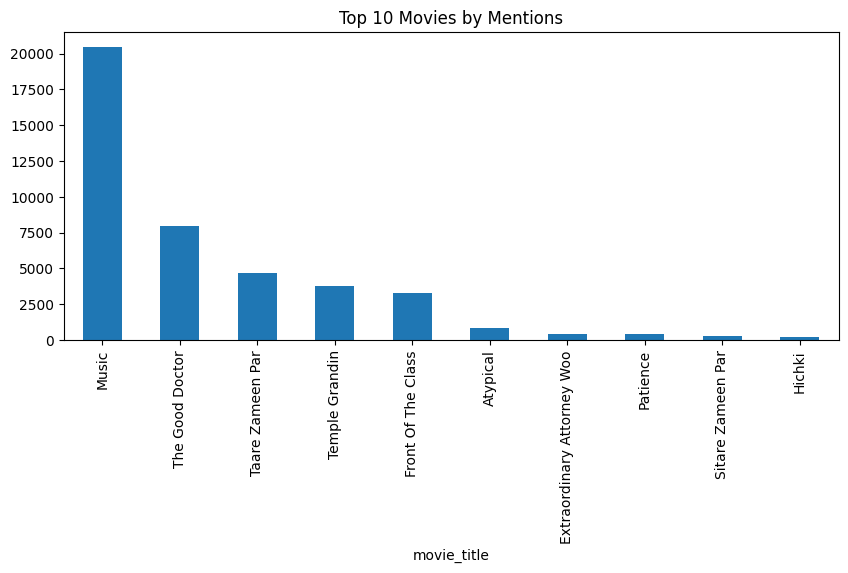

In [88]:
import matplotlib.pyplot as plt
master_df['movie_title'].value_counts().head(10).plot(kind='bar', figsize=(10,4))
plt.title("Top 10 Movies by Mentions")
plt.show()


In [90]:
master_df['final_text'] = master_df['translated_text'].fillna(master_df['text'])